In [1]:
import csv
import sqlalchemy as db
from sqlalchemy import func
import matplotlib.pyplot as plt

In [2]:
engine = db.create_engine("sqlite:///:memory:")
metadata = db.MetaData()

In [3]:
unkn_table = db.Table(
    'unkn_table',metadata,
    db.Column('PassengerId', db.Integer, primary_key=True),
    db.Column('Survived', db.Integer),
    db.Column('Sex', db.Integer),
    db.Column('Pclass_1', db.Integer),
    db.Column('Pclass_2', db.Integer),
    db.Column('Pclass_3', db.Integer),
    db.Column('Fare', db.Float),
)
metadata.create_all(engine)

In [4]:
with open('train_data.csv', mode='r', encoding='utf-8') as file:
    # DictReader сделает в каждом словаре ключами названия колонок
    csv_reader = csv.DictReader(file)
    data_to_insert = []
    # делаем список из словарей
    for row in csv_reader:
        data_to_insert.append({
            'PassengerId': int(row['PassengerId']),
            'Survived': int(row['Survived']),
            'Sex': int(float(row['Sex'])),
            'Pclass_1': int(float(row['Pclass_1'])),
            'Pclass_2': int(float(row['Pclass_2'])),
            'Pclass_3': int(float(row['Pclass_3'])),
            'Fare': float(row['Fare'])
        })

In [5]:
with engine.connect() as conn:
    conn.execute(unkn_table.insert(), data_to_insert)
    conn.commit()

получаем: пол, выжил, сколько таких людей

где "0" и "1" - "ж" и "м", "0" и "1" - "погиб" и "выжил", количество людей

на выходе получаем все варианты комбинаций пола и статуса


In [6]:
query = db.select(
    unkn_table.columns.Sex,
    unkn_table.columns.Survived,
    func.count(unkn_table.columns.PassengerId).label('total')
).group_by(
    unkn_table.columns.Sex,
    unkn_table.columns.Survived
)

with engine.connect() as conn:
    raw_stats = conn.execute(query).fetchall()
raw_stats

[(0, 0, 70), (0, 1, 209), (1, 0, 416), (1, 1, 97)]

ж умерло 70;
ж живо 209;
м умерло 416;
м живо 97

Полученные данные указываем для дальнейшего использования в сгруппированной столбчатрй диаграмме

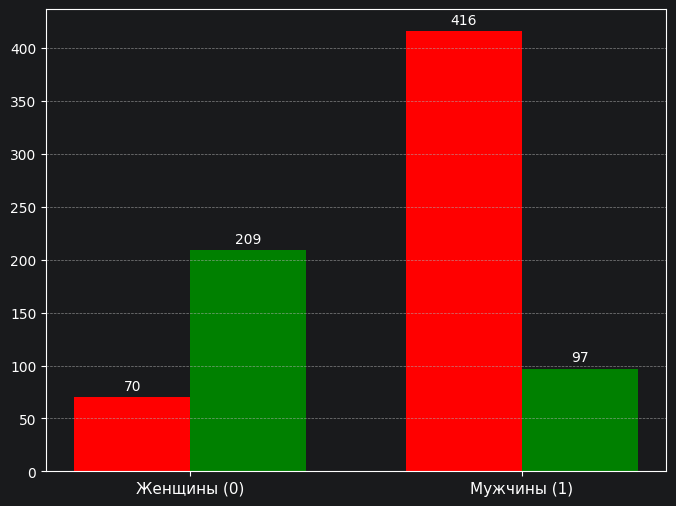

In [8]:
women_died = 70
women_survived = 209
men_died = 416
men_survived = 97
# делаем списки которые принимает библиотека
categories = ['Женщины (0)', 'Мужчины (1)']
died_counts = [women_died, men_died] # [70, 416]
survived_counts = [women_survived, men_survived] # [209, 97]

# настройка позиций для столбиков (чтобы они стояли рядом, а не друг на друге)
x = [0, 1]  # координаты групп на оси X
width = 0.35  # ширина каждого столбика

# рисуем графики
fig, ax = plt.subplots(figsize=(8, 6))

# столбики для погибших (красные)
rects1 = ax.bar([pos - width/2 for pos in x], died_counts, width, label='Погибли', color='#ff0000')
# Столбики для выживших (зеленые)
rects2 = ax.bar([pos + width/2 for pos in x], survived_counts, width, label='Выжили', color='#008000')

# добавляем сетку
ax.grid(axis='y', linestyle='--', alpha=0.7)  # добавляем легкую сетку для удобства
ax.set_xticks([0, 1]) # отмечаем места где должны быть разметки с обозрачениями оси х
                      # где центр женской группы будет на 0, а мужской на 1
ax.set_xticklabels(['Женщины (0)', 'Мужчины (1)'], fontsize=11) # добавляем сами обозначения

# добавляем цифры над каждым столбиком
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.show()

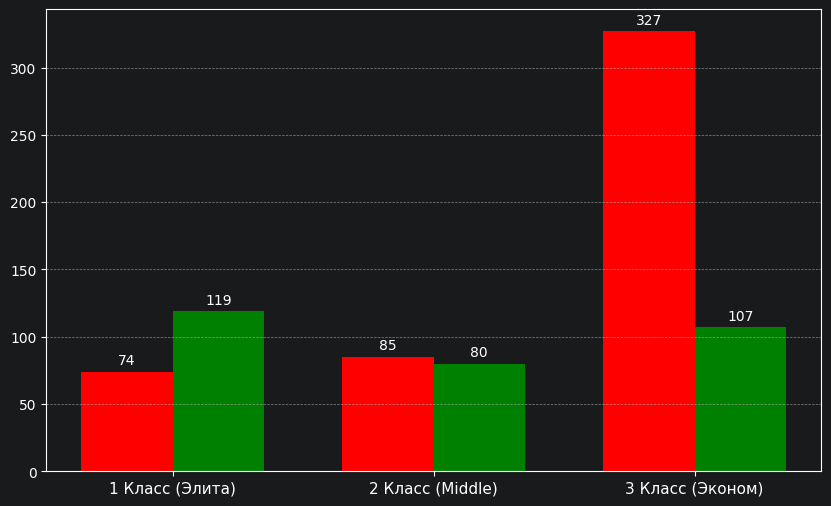

In [10]:
# собираем данные из каждого класса кают и сразу пишем к ним запрос
pclass_stats = {}

with engine.connect() as conn:
    for pclass_col in ['Pclass_1', 'Pclass_2', 'Pclass_3']:
        query = db.select(
            # статус выживания и количество
            unkn_table.columns.Survived,
            func.count(unkn_table.columns.PassengerId)
        ).where(
            # выбираем тех кто точно плыл в текущем классе цикла
            unkn_table.columns[pclass_col] == 1
        ).group_by(
            unkn_table.columns.Survived
        )

        result = conn.execute(query).fetchall()
# делаем словарь из [статус выживания: количество] на оба статуса в виде значения и с ключом в виде класса
        pclass_stats[pclass_col] = dict(result)

# список для библиотеки
categories = ['1 Класс (Элита)', '2 Класс (Middle)', '3 Класс (Эконом)']

# получаем значения умерших поскольку словарь: 'Pclass_1': {0: 80, 1: 136}
died_counts = [
    pclass_stats['Pclass_1'].get(0, 0),
    pclass_stats['Pclass_2'].get(0, 0),
    pclass_stats['Pclass_3'].get(0, 0)
]
# получаем значения выживших
survived_counts = [
    pclass_stats['Pclass_1'].get(1, 0),
    pclass_stats['Pclass_2'].get(1, 0),
    pclass_stats['Pclass_3'].get(1, 0)
]

width = 0.35                # ширина столбиков чтоб не слиплись

fig, ax = plt.subplots(figsize=(10, 6))

# рисуем пары столбиков со смещением относительно центра x
rects1 = ax.bar([pos - width/2 for pos in x], died_counts, width, label='Погибли', color='#ff0000')
rects2 = ax.bar([pos + width/2 for pos in x], survived_counts, width, label='Выжили', color='#008000')

# рисуем сетку значений
ax.grid(axis='y', linestyle='--', alpha=0.7)
# разграничиваем группы (точки 0, 1 и 2)
ax.set_xticks([0, 1, 2])

# пишем названия
ax.set_xticklabels(['1 Класс (Элита)', '2 Класс (Middle)', '3 Класс (Эконом)'], fontsize=11)

# подписываем точные значения над каждым столбиком
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.show()

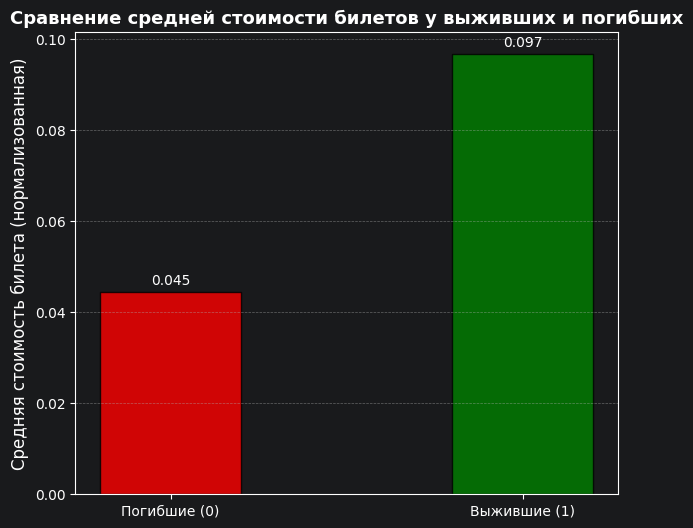

In [12]:
# сгруппировать по статусу выживания и посчитать среднюю цену(Fare)
query_fare = db.select(
    unkn_table.columns.Survived,
    func.avg(unkn_table.columns.Fare)
).group_by(
    unkn_table.columns.Survived
)

with engine.connect() as conn:
    # словарь вида {0: цена_умерших, 1: цена_выживших}
    fare_stats = dict(conn.execute(query_fare).fetchall())

# списки для библы
# подписываем ось х что бы не плыло по значениям оси, а рисовало в категориальном графике(т.к. всего 2 столбика)
labels = ['Погибшие (0)', 'Выжившие (1)']
average_fares = [fare_stats.get(0, 0), fare_stats.get(1, 0)]

# рисуем график
fig, ax = plt.subplots(figsize=(7, 6))

# красный для погибших, зеленый для выживших
colors = ['#ff0000', '#008000']
rects = ax.bar(labels, average_fares, color=colors, width=0.4, edgecolor='black', alpha=0.8)

# подписываем ось у
ax.set_ylabel('Средняя стоимость билета (нормализованная)', fontsize=12)
# подписываем ось х
ax.set_title('Сравнение средней стоимости билетов у выживших и погибших', fontsize=13, fontweight='bold')
# сетка
ax.grid(axis='y', linestyle='--', alpha=0.5)

# добавляем цифровые метки над столбиками(округляем до 3 знаков после запятой)
ax.bar_label(rects, padding=3, fmt='%.3f')

plt.show()